In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import contextlib
import copy
import io
import os
import queue
import threading
from datetime import date
from itertools import product
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
from sklearn.metrics import root_mean_squared_error, r2_score

from aquacrop import AquaCrop, Crop, Soil, Weather
from aquacrop_slovenia import config
from aquacrop_slovenia.diagnostics import nse, kge, mkge, kge_r, kge_beta, kge_alpha, mkge_alpha
from aquacrop_slovenia.plots import plot_yield_timeseries_comparison, plot_yield_scatter, plot_yield_timeseries_residuals
from aquacrop_slovenia.reading_data import get_yield, get_yield_for_comparison, get_co2_for_aquacrop, get_station_weather
from aquacrop_slovenia.parameters_running_jablje import (
    jablje_soil_layers,
    jablje_curve_number,
    jablje_readily_evaporable_water,
    jablje_maize_params,
    jablje_optimal_management,
    jablje_initial_cond,
    jablje_groundwater,
)

Loaded data sizes: Temperatures=1096, ETo=1096, Rain=1096


In [3]:
LOCATION = "jablje"
MAX_WORKERS = os.cpu_count()

simulation_periods = [
    {
        "start_date": date(year, 1, 1),
        "end_date": date(year, 12, 31),
        "planting_date": date(year, 5, 3),
        "is_seeding_year": True,
    }
    for year in range(1993, 2024)
    if year not in [2017]
]

temperatures, eto, rain = get_station_weather(8)
historical_co2 = get_co2_for_aquacrop("historical")

weather = Weather(
    location=LOCATION,
    temperatures=temperatures,
    eto_values=eto,
    rainfall_values=rain,
    record_type=1,
    first_day=1,
    first_month=1,
    first_year=1993,
    co2_records=historical_co2,
)

soil = Soil(
    name=f"{LOCATION} soil",
    description=f"{LOCATION} loamy sand soil",
    soil_layers=jablje_soil_layers,
    curve_number=jablje_curve_number,
    readily_evaporable_water=jablje_readily_evaporable_water,
)

observed_biomass = get_yield_for_comparison(LOCATION, "biomass", "A", "N3")
observed_grain = get_yield_for_comparison(LOCATION, "grain", "A", "N3")

INTEGER_PARAMS = {name for name, val in jablje_maize_params.items() if isinstance(val, int)}

In [4]:
# Parameters to search and their grid values (bounds from Optimization Jablje)
grid_params = {
    #"harvest_index":        np.linspace(0.46, 0.56, 6),
    #"gdd_senescence":       np.linspace(1000, 1150, 5),
    #"gdd_maturity":         np.linspace(1200, 1400, 5),
    #"gdd_flowering":        np.linspace(480, 530, 5),
    #"gdd_flowering_length": np.linspace(130, 170, 3),
    "max_canopy_cover":     np.linspace(0.85, 0.95, 3), # zacasno
    #"min_rooting_depth":    np.linspace(0.2, 0.4, 3),
    "max_rooting_depth":    np.linspace(0.5, 2.5, 5),
    "ksat":                 np.array([5., 20., 100., 575., 1000.]),
    "cgc_gdd":              np.linspace(0.010, 0.015, 4),
    "p_upper_stomata": [0.3, 0.4, 0.5, 0.6, 0.7],
    "p_upper_senescence": [0.3, 0.4, 0.5, 0.6, 0.7],
}

SOIL_PARAMS = {"ksat"}

param_names = list(grid_params.keys())
grid_combinations = list(product(*grid_params.values()))

grid_shape = " x ".join(str(len(v)) for v in grid_params.values())
print(f"Grid: {grid_shape} = {len(grid_combinations):,} combinations")
print(f"Workers: {MAX_WORKERS}")

Grid: 3 x 5 x 5 x 4 x 5 x 5 = 7,500 combinations
Workers: 28


In [5]:
# Pre-create one working directory per worker to avoid conflicts
worker_dirs = []
for i in range(MAX_WORKERS):
    d = config.MODEL_RUNNING_DIR / f"grid_jablje_{i}"
    d.mkdir(parents=True, exist_ok=True)
    worker_dirs.append(d)

dir_queue = queue.Queue()
for d in worker_dirs:
    dir_queue.put(d)

print(f"Worker directories: {[str(d) for d in worker_dirs]}")

Worker directories: ['E:aquacrop\\grid_jablje_0', 'E:aquacrop\\grid_jablje_1', 'E:aquacrop\\grid_jablje_2', 'E:aquacrop\\grid_jablje_3', 'E:aquacrop\\grid_jablje_4', 'E:aquacrop\\grid_jablje_5', 'E:aquacrop\\grid_jablje_6', 'E:aquacrop\\grid_jablje_7', 'E:aquacrop\\grid_jablje_8', 'E:aquacrop\\grid_jablje_9', 'E:aquacrop\\grid_jablje_10', 'E:aquacrop\\grid_jablje_11', 'E:aquacrop\\grid_jablje_12', 'E:aquacrop\\grid_jablje_13', 'E:aquacrop\\grid_jablje_14', 'E:aquacrop\\grid_jablje_15', 'E:aquacrop\\grid_jablje_16', 'E:aquacrop\\grid_jablje_17', 'E:aquacrop\\grid_jablje_18', 'E:aquacrop\\grid_jablje_19', 'E:aquacrop\\grid_jablje_20', 'E:aquacrop\\grid_jablje_21', 'E:aquacrop\\grid_jablje_22', 'E:aquacrop\\grid_jablje_23', 'E:aquacrop\\grid_jablje_24', 'E:aquacrop\\grid_jablje_25', 'E:aquacrop\\grid_jablje_26', 'E:aquacrop\\grid_jablje_27']


In [6]:
def evaluate_params(param_values):
    """Run one grid point and return parameter values + all scores for both grain and biomass."""
    working_dir = dir_queue.get()
    try:
        params = copy.deepcopy(jablje_maize_params)
        soil_vals = {}
        for name, val in zip(param_names, param_values):
            if name in SOIL_PARAMS:
                soil_vals[name] = float(val)
            else:
                params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

        if soil_vals:
            layers = copy.deepcopy(jablje_soil_layers)
            for layer in layers:
                for k, v in soil_vals.items():
                    setattr(layer, k, v)
            current_soil = Soil(
                name=f"{LOCATION} soil",
                description=f"{LOCATION} loamy sand soil",
                soil_layers=layers,
                curve_number=jablje_curve_number,
                readily_evaporable_water=jablje_readily_evaporable_water,
            )
        else:
            current_soil = soil

        crop = Crop(
            name=f"{LOCATION} maize",
            description="grid search",
            params=params,
        )

        simulation = AquaCrop(
            simulation_periods=simulation_periods,
            crop=crop,
            soil=current_soil,
            management=jablje_optimal_management,
            initial_conditions=jablje_initial_cond,
            climate=weather,
            #ground_water=jablje_groundwater,
            working_dir=working_dir,
            need_daily_output=False,
            need_seasonal_output=True,
            need_harvest_output=False,
            need_evaluation_output=False,
        )

        nan_metrics = {f"{prefix}_{s}": np.nan
                       for prefix in ("biomass", "grain")
                       for s in ["rmse", "r2", "nse", "kge", "mkge", "kge_r", "kge_beta", "kge_alpha", "mkge_alpha"]}

        try:
            with contextlib.redirect_stdout(io.StringIO()):
                results = simulation.run()
        except Exception:
            return {**dict(zip(param_names, param_values)), **nan_metrics}

        seasonal = results["season"][["Year1", "BioMass", "Y(dry)"]].rename(
            columns={"Year1": "year", "BioMass": "biomass_modeled", "Y(dry)": "grain_modeled"}
        )

        def compute_metrics(observed_df, modeled_col, prefix):
            merged = observed_df.merge(seasonal[["year", modeled_col]], on="year")
            y_obs = merged["yield"].values
            y_mod = merged[modeled_col].values
            return {
                f"{prefix}_rmse":       root_mean_squared_error(y_obs, y_mod),
                f"{prefix}_r2":         r2_score(y_obs, y_mod),
                f"{prefix}_nse":        nse(y_mod, y_obs),
                f"{prefix}_kge":        kge(y_mod, y_obs),
                f"{prefix}_mkge":       mkge(y_mod, y_obs),
                f"{prefix}_kge_r":      kge_r(y_mod, y_obs),
                f"{prefix}_kge_beta":   kge_beta(y_mod, y_obs),
                f"{prefix}_kge_alpha":  kge_alpha(y_mod, y_obs),
                f"{prefix}_mkge_alpha": mkge_alpha(y_mod, y_obs),
            }

        return {
            **dict(zip(param_names, param_values)),
            **compute_metrics(observed_biomass, "biomass_modeled", "biomass"),
            **compute_metrics(observed_grain, "grain_modeled", "grain"),
        }
    finally:
        dir_queue.put(working_dir)

360 simulacij / 1 minuto

In [7]:
total = len(grid_combinations)
results_list = []

print(f"Running {total:,} simulations with {MAX_WORKERS} workers...")
print(f"Approximate running time: {total // 340} min")

with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    futures = [executor.submit(evaluate_params, combo) for combo in grid_combinations]
    for future in as_completed(futures):
        results_list.append(future.result())

results_df = pd.DataFrame(results_list).sort_values("grain_rmse").reset_index(drop=True)
print(f"\nComplete. Failed runs: {results_df['biomass_rmse'].isna().sum()}")

Running 7,500 simulations with 28 workers...
Approximate running time: 22 min


C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(predictions, targets)[0]
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:70: RuntimeWarning: invalid value encountered in scalar divide
  return (np.std(predictions) / np.std(targets)) / kge_beta(predictions, targets)
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(predictions, targets)[0]
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:70: RuntimeWarning: invalid value encountered in scalar divide
  return (np.std(predictions) / np.std(targets)) / kge_beta(predictions, targets)
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarnin

AquaCrop simulation completed successfully
AquaCrop simulation completed successfully
Parsing simulation results...
Results successfully parsed


C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(predictions, targets)[0]
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:70: RuntimeWarning: invalid value encountered in scalar divide
  return (np.std(predictions) / np.std(targets)) / kge_beta(predictions, targets)
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return pearsonr(predictions, targets)[0]
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:70: RuntimeWarning: invalid value encountered in scalar divide
  return (np.std(predictions) / np.std(targets)) / kge_beta(predictions, targets)
C:\Users\rokku\Documents\Code\aquacrop-slovenia\aquacrop_slovenia\diagnostics.py:58: ConstantInputWarnin

In [8]:
output_path = config.RESULTS_DIR / "grid_search_jablje_8_biomass.pkl"
results_df.to_pickle(output_path)
print(f"Saved {len(results_df):,} rows to {output_path}")

In [9]:
output_path = config.RESULTS_DIR / "grid_search_jablje_8_biomass.pkl"
results_df = pd.read_pickle(output_path)

In [10]:
results_df.sort_values("biomass_rmse", ascending=False).reset_index(drop=True)

,max_canopy_cover,max_rooting_depth,ksat,cgc_gdd,p_upper_stomata,p_upper_senescence,biomass_rmse,biomass_r2,biomass_nse,biomass_kge,...,biomass_mkge_alpha,grain_rmse,grain_r2,grain_nse,grain_kge,grain_mkge,grain_kge_r,grain_kge_beta,grain_kge_alpha,grain_mkge_alpha
0,0.85,0.5,5.0,0.010000,0.3,0.3,18.488616,-17.131149,-17.131149,-0.654652,...,3.076876,9.636081,-21.052593,-21.052593,NaN,NaN,NaN,0.000000,0.000000,NaN
1,0.90,0.5,5.0,0.010000,0.3,0.3,18.488533,-17.130986,-17.130986,-0.654789,...,3.079148,9.636081,-21.052593,-21.052593,NaN,NaN,NaN,0.000000,0.000000,NaN
2,0.95,0.5,5.0,0.010000,0.3,0.3,18.488390,-17.130706,-17.130706,-0.654620,...,3.080855,9.636081,-21.052593,-21.052593,NaN,NaN,NaN,0.000000,0.000000,NaN
3,0.85,0.5,5.0,0.010000,0.4,0.3,18.478461,-17.111236,-17.111236,-0.652900,...,2.848200,9.636081,-21.052593,-21.052593,NaN,NaN,NaN,0.000000,0.000000,NaN
4,0.90,0.5,5.0,0.010000,0.4,0.3,18.478391,-17.111099,-17.111099,-0.652829,...,2.850002,9.636081,-21.052593,-21.052593,NaN,NaN,NaN,0.000000,0.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7495,0.95,1.0,1000.0,0.013333,0.3,0.6,4.085533,0.114652,0.114652,0.074086,...,0.350534,2.321215,-0.279645,-0.279645,0.182160,0.233590,0.468005,0.846852,0.398012,0.469990
7496,0.95,1.0,1000.0,0.013333,0.3,0.7,4.084397,0.115144,0.115144,0.073709,...,0.349315,2.321251,-0.279684,-0.279684,0.181139,0.232439,0.467324,0.846947,0.397203,0.468981
7497,0.85,1.0,1000.0,0.015000,0.3,0.5,4.083285,0.115626,0.115626,0.082747,...,0.359273,2.203915,-0.153582,-0.153582,0.197528,0.242623,0.473042,0.866834,0.409624,0.472552
7498,0.95,1.0,575.0,0.013333,0.3,0.5,4.079668,0.117192,0.117192,0.087039,...,0.364675,2.318504,-0.276658,-0.276658,0.196260,0.249413,0.480757,0.845545,0.406260,0.480470


In [11]:
best = {}

In [23]:
# Re-run with the best parameter set (lowest RMSE) to get full seasonal results for plotting
results_df_sorted = results_df.sort_values("grain_mkge", ascending=False).reset_index(drop=True)
best = results_df_sorted.iloc[0]

best_params = copy.deepcopy(jablje_maize_params)
best_soil_vals = {}
for name in param_names:
    val = best[name]
    if name in SOIL_PARAMS:
        best_soil_vals[name] = float(val)
    else:
        best_params[name] = int(round(val)) if name in INTEGER_PARAMS else float(val)

if best_soil_vals:
    best_layers = copy.deepcopy(jablje_soil_layers)
    for layer in best_layers:
        for k, v in best_soil_vals.items():
            setattr(layer, k, v)
    best_soil = Soil(
        name=f"{LOCATION} soil",
        description=f"{LOCATION} loamy sand soil",
        soil_layers=best_layers,
        curve_number=jablje_curve_number,
        readily_evaporable_water=jablje_readily_evaporable_water,
    )
else:
    best_soil = soil

best_crop = Crop(
    name=f"{LOCATION} maize (best grid)",
    description="best grid search parameters",
    params=best_params,
)

best_dir = config.MODEL_RUNNING_DIR / "grid_jablje_best"
best_dir.mkdir(parents=True, exist_ok=True)

best_simulation = AquaCrop(
    simulation_periods=simulation_periods,
    crop=best_crop,
    soil=best_soil,
    management=jablje_optimal_management,
    initial_conditions=jablje_initial_cond,
    climate=weather,
    #ground_water=jablje_groundwater,
    working_dir=best_dir,
    need_daily_output=False,
    need_seasonal_output=True,
    need_harvest_output=False,
    need_evaluation_output=False,
)

best_results = best_simulation.run()
best_seasonal = best_results["season"]

In [24]:
best_params

{'crop_type': 2,
 'is_sown': True,
 'cycle_determination': 0,
 'adjust_for_eto': True,
 'base_temp': 10.0,
 'upper_temp': 30.0,
 'gdd_cycle_length': 1058,
 'dormancy_eto_threshold': 50,
 'p_upper_canopy': 0.14,
 'p_lower_canopy': 0.72,
 'shape_canopy': 2.9,
 'p_upper_stomata': 0.5,
 'shape_stomata': 6.0,
 'p_upper_senescence': 0.7,
 'shape_senescence': 2.7,
 'p_upper_pollination': 0.8,
 'aeration_stress_threshold': 5,
 'fertility_stress_calibration': 50,
 'shape_fertility_canopy_expansion': 25,
 'shape_fertility_max_canopy': 25,
 'shape_fertility_water_productivity': 25,
 'shape_fertility_decline': 25,
 'cold_stress_for_pollination': 10,
 'heat_stress_for_pollination': 40,
 'minimum_growing_degrees_pollination': 12.0,
 'salinity_threshold_ece': 2,
 'salinity_max_ece': 10,
 'salinity_shape_factor': -9,
 'salinity_stress_cc': 25,
 'salinity_stress_stomata': 100,
 'kc_max': 1.05,
 'kc_decline': 0.3,
 'min_rooting_depth': 0.3,
 'max_rooting_depth': 0.5,
 'root_expansion_shape': 13,
 'max_w

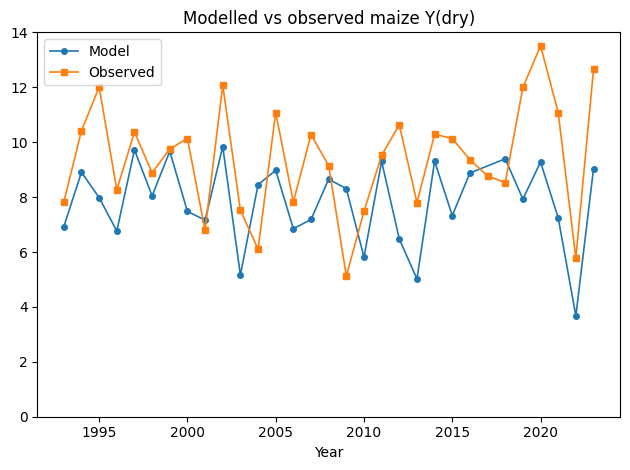

In [25]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"), "Y(dry)", LOCATION)

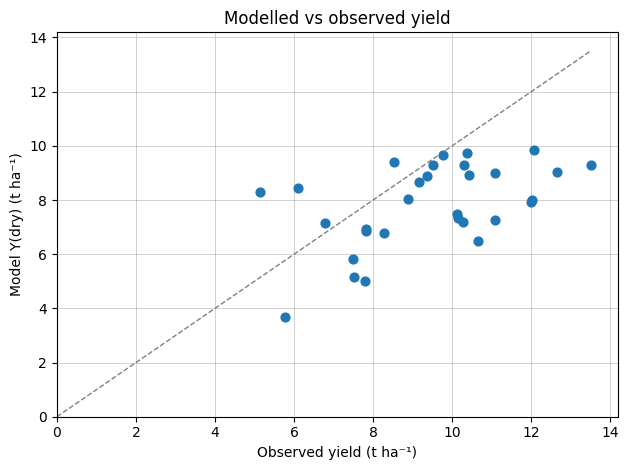

In [26]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "grain", "A", "N3"))

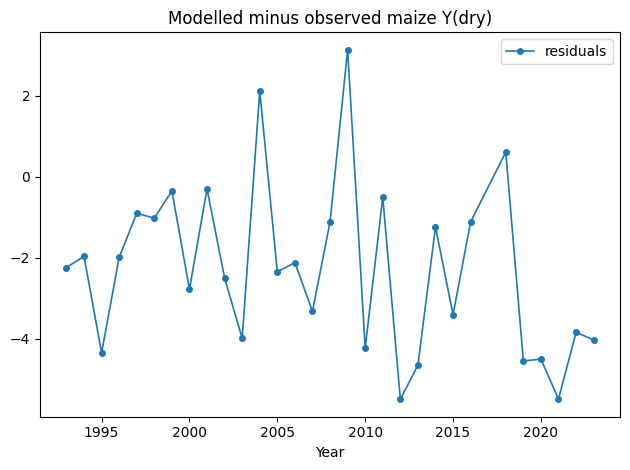

In [15]:
plot_yield_timeseries_residuals(best_seasonal, get_yield_for_comparison(LOCATION, "grain", "A", "N3"), "Y(dry)")

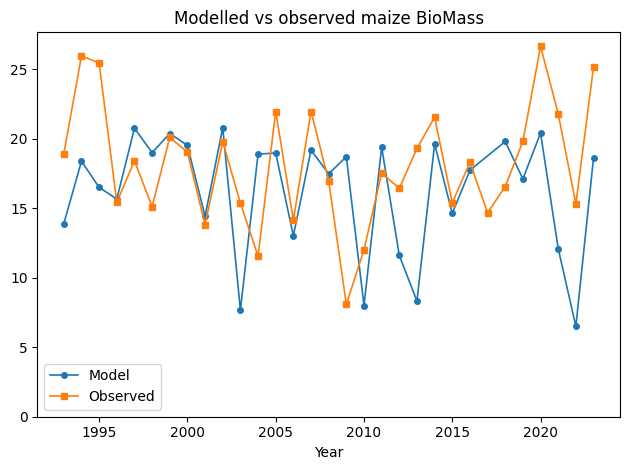

In [16]:
plot_yield_timeseries_comparison(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"), "BioMass", LOCATION)

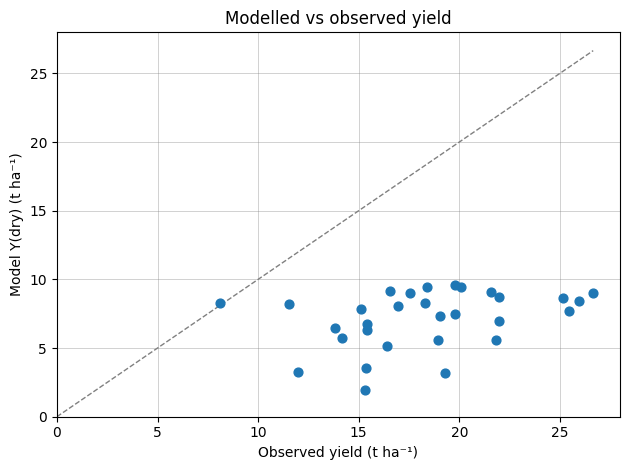

In [17]:
plot_yield_scatter(best_seasonal, get_yield(LOCATION, "biomass", "A", "N3"))